In [ ]:
"""
CBIS-DDSM 良性 vs 惡性 CNN — v2 改進版
======================================
v2 相對 v1 的改動：
1. 影像策略：用 roi_mask 找病灶 bounding box，從 full_image 裁切 (含 30% margin)
   → 比 roi_cropped 解析度高，又比 full_image 訊號集中
2. 模型：ResNet50 → ResNet18 (495 張資料用較小模型不易 overfit)
3. 推論：加 Test-Time Augmentation (TTA)
4. 訓練更久 (15 → 30 epoch)，加 early stopping
"""

In [ ]:
import os
import sys
import random
from pathlib import Path
from collections import Counter

In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from torchvision import models
from PIL import Image
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt

============================================================
1. 環境偵測
============================================================

In [ ]:
IN_COLAB = "google.colab" in sys.modules

In [ ]:
if IN_COLAB:
    DATA_ROOT = Path("/content/data/CBIS_DDSM_Kaggle")
    if not DATA_ROOT.exists():
        from google.colab import files
        kaggle_dir = Path.home() / ".kaggle"
        kaggle_dir.mkdir(exist_ok=True)
        if not (kaggle_dir / "kaggle.json").exists():
            print("請上傳你的 kaggle.json：")
            files.upload()
            Path("kaggle.json").rename(kaggle_dir / "kaggle.json")
            os.chmod(kaggle_dir / "kaggle.json", 0o600)
        os.system("pip install -q kaggle")
        os.system("kaggle datasets download -d dynemiesizumaki/cbis-ddsmpng "
                  "-p /content/data --unzip")
else:
    DATA_ROOT = Path(r"C:\Users\s9988\Documents\datasets\cbis-ddsm\CBIS_DDSM_Kaggle")

請上傳你的 kaggle.json：


Saving kaggle.json to kaggle.json


In [ ]:
assert DATA_ROOT.exists(), f"找不到資料集: {DATA_ROOT}"
print(f"資料集路徑: {DATA_ROOT}")

資料集路徑: /content/data/CBIS_DDSM_Kaggle


============================================================
2. 超參數
============================================================

In [ ]:
CONFIG = {
    "img_size":     224,
    "batch_size":   32,
    "num_epochs":   30,
    "patience":     8,           # early stopping
    "lr":           1e-4,
    "weight_decay": 1e-4,
    "val_split":    0.15,
    "test_split":   0.15,
    "num_workers":  2 if IN_COLAB else 0,
    "seed":         42,
    "bbox_margin":  0.30,        # bbox 往外擴 30% 抓 context
    "tta_n":        5,           # TTA 平均的 augmented 版本數
}

In [ ]:
torch.manual_seed(CONFIG["seed"])
np.random.seed(CONFIG["seed"])
random.seed(CONFIG["seed"])

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Device: cuda
GPU: Tesla T4


============================================================
3. 掃描資料夾 (需要同時有 full_image.png + roi_mask.png)
============================================================

In [ ]:
def scan_dataset(root: Path) -> pd.DataFrame:
    rows = []
    for class_name, label in {"BENIGN": 0, "MALIGNANT": 1}.items():
        class_dir = root / class_name
        if not class_dir.exists():
            continue
        for case_dir in class_dir.iterdir():
            if not case_dir.is_dir():
                continue
            full_img = case_dir / "full_image.png"
            mask     = case_dir / "roi_mask.png"
            if not (full_img.exists() and mask.exists()):
                continue
            parts = case_dir.name.split("_")
            patient_id = f"{parts[0]}_{parts[1]}"
            rows.append({
                "full_image_path": str(full_img),
                "mask_path":       str(mask),
                "label":           label,
                "patient_id":      patient_id,
                "case_id":         case_dir.name,
                "class":           class_name,
            })
    return pd.DataFrame(rows)

In [ ]:
df = scan_dataset(DATA_ROOT)
print(f"\n總影像數 (full_image + mask 都存在): {len(df)}")
print(f"類別分布:\n{df['class'].value_counts()}")
print(f"獨立病人數: {df['patient_id'].nunique()}")


總影像數 (full_image + mask 都存在): 458
類別分布:
class
BENIGN       269
MALIGNANT    189
Name: count, dtype: int64
獨立病人數: 398


============================================================
4. 病人層級切分
============================================================

In [ ]:
def patient_split(df, val_size, test_size, seed):
    gss1 = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=seed)
    tv_idx, te_idx = next(gss1.split(df, groups=df["patient_id"]))
    df_tv, df_te = df.iloc[tv_idx].reset_index(drop=True), df.iloc[te_idx].reset_index(drop=True)
    val_ratio = val_size / (1.0 - test_size)
    gss2 = GroupShuffleSplit(n_splits=1, test_size=val_ratio, random_state=seed)
    tr_idx, val_idx = next(gss2.split(df_tv, groups=df_tv["patient_id"]))
    return (df_tv.iloc[tr_idx].reset_index(drop=True),
            df_tv.iloc[val_idx].reset_index(drop=True),
            df_te)

In [ ]:
df_train, df_val, df_test = patient_split(
    df, CONFIG["val_split"], CONFIG["test_split"], CONFIG["seed"]
)
print(f"\nTrain: {len(df_train)} | Val: {len(df_val)} | Test: {len(df_test)}")
print(f"Train: {df_train['class'].value_counts().to_dict()}")
print(f"Val:   {df_val['class'].value_counts().to_dict()}")
print(f"Test:  {df_test['class'].value_counts().to_dict()}")
assert not (set(df_train["patient_id"]) & set(df_val["patient_id"]))
assert not (set(df_train["patient_id"]) & set(df_test["patient_id"]))
assert not (set(df_val["patient_id"]) & set(df_test["patient_id"]))


Train: 310 | Val: 77 | Test: 71
Train: {'BENIGN': 181, 'MALIGNANT': 129}
Val:   {'BENIGN': 46, 'MALIGNANT': 31}
Test:  {'BENIGN': 42, 'MALIGNANT': 29}


============================================================
5. 從 mask 抓 bounding box，從 full_image 裁切
============================================================

In [ ]:
def get_lesion_bbox(mask_path: str, margin_ratio: float):
    """讀 mask，找非零區域的 bbox，往外擴 margin_ratio 倍。"""
    mask = np.array(Image.open(mask_path).convert("L"))
    ys, xs = np.where(mask > 0)
    if len(xs) == 0:
        return None
    H, W = mask.shape
    y0, y1 = int(ys.min()), int(ys.max())
    x0, x1 = int(xs.min()), int(xs.max())
    bh, bw = y1 - y0, x1 - x0
    my, mx = int(bh * margin_ratio), int(bw * margin_ratio)
    return (max(0, x0 - mx), max(0, y0 - my),
            min(W, x1 + mx), min(H, y1 + my))

In [ ]:
class CBISMaskedCropDataset(Dataset):
    """讀 full_image，用 mask bbox 裁切 (含 margin)"""
    def __init__(self, df, transform=None, margin=0.30):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        self.margin = margin

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["full_image_path"]).convert("RGB")
        bbox = get_lesion_bbox(row["mask_path"], self.margin)
        if bbox is not None:
            img = img.crop(bbox)
        if self.transform:
            img = self.transform(img)
        return img, int(row["label"])

============================================================
6. Transforms
============================================================

In [ ]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

In [ ]:
train_tfm = T.Compose([
    T.Resize((CONFIG["img_size"] + 32, CONFIG["img_size"] + 32)),
    T.RandomCrop(CONFIG["img_size"]),
    T.RandomHorizontalFlip(),
    T.RandomVerticalFlip(),
    T.RandomRotation(20),
    T.ColorJitter(brightness=0.15, contrast=0.15),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

In [ ]:
eval_tfm = T.Compose([
    T.Resize((CONFIG["img_size"], CONFIG["img_size"])),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

In [ ]:
# TTA 用：跟 train_tfm 一樣有隨機性，但較溫和
tta_tfm = T.Compose([
    T.Resize((CONFIG["img_size"] + 16, CONFIG["img_size"] + 16)),
    T.RandomCrop(CONFIG["img_size"]),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomVerticalFlip(p=0.5),
    T.RandomRotation(15),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

In [ ]:
train_ds = CBISMaskedCropDataset(df_train, train_tfm, CONFIG["bbox_margin"])
val_ds   = CBISMaskedCropDataset(df_val,   eval_tfm, CONFIG["bbox_margin"])
test_ds  = CBISMaskedCropDataset(df_test,  eval_tfm, CONFIG["bbox_margin"])

In [ ]:
mk_loader = lambda ds, shuffle: DataLoader(
    ds, batch_size=CONFIG["batch_size"], shuffle=shuffle,
    num_workers=CONFIG["num_workers"], pin_memory=True,
)
train_loader = mk_loader(train_ds, True)
val_loader   = mk_loader(val_ds,   False)
test_loader  = mk_loader(test_ds,  False)

============================================================
7. ResNet18 (改用較小模型)
============================================================

In [ ]:
def build_model(num_classes=2):
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    for p in model.parameters():
        p.requires_grad = False
    for p in model.layer4.parameters():
        p.requires_grad = True
    model.fc = nn.Sequential(
        nn.Dropout(0.4),
        nn.Linear(model.fc.in_features, num_classes),
    )
    return model

In [ ]:
model = build_model(2).to(device)
n_train = sum(p.numel() for p in model.parameters() if p.requires_grad)
n_total = sum(p.numel() for p in model.parameters())
print(f"\n可訓練參數: {n_train:,} / 總參數: {n_total:,}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 199MB/s]



可訓練參數: 8,394,754 / 總參數: 11,177,538


============================================================
8. Loss + Optimizer
============================================================

In [ ]:
cnt = Counter(df_train["label"].tolist())
total = sum(cnt.values())
class_weights = torch.tensor(
    [total / (2 * cnt[i]) for i in [0, 1]], dtype=torch.float
).to(device)
print(f"類別權重 (BENIGN, MALIGNANT): {class_weights.cpu().tolist()}")

類別權重 (BENIGN, MALIGNANT): [0.8563535809516907, 1.2015503644943237]


In [ ]:
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.AdamW(
    [p for p in model.parameters() if p.requires_grad],
    lr=CONFIG["lr"], weight_decay=CONFIG["weight_decay"],
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=CONFIG["num_epochs"]
)

============================================================
9. 訓練 + Early Stopping
============================================================

In [ ]:
def evaluate(model, loader):
    model.eval()
    labels, probs, preds = [], [], []
    total_loss = 0.0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            total_loss += criterion(logits, y).item() * x.size(0)
            p = torch.softmax(logits, 1)[:, 1]
            labels.extend(y.cpu().tolist())
            probs.extend(p.cpu().tolist())
            preds.extend(logits.argmax(1).cpu().tolist())
    return {
        "loss": total_loss / len(loader.dataset),
        "acc":  float(np.mean(np.array(labels) == np.array(preds))),
        "auc":  roc_auc_score(labels, probs) if len(set(labels)) > 1 else float("nan"),
        "labels": labels, "probs": probs, "preds": preds,
    }

In [ ]:
best_auc = 0.0
patience_counter = 0
history = {"train_loss": [], "val_loss": [], "val_acc": [], "val_auc": []}
CKPT = "best_model_v2.pt"

In [ ]:
print("\n=== 開始訓練 ===")
for epoch in range(1, CONFIG["num_epochs"] + 1):
    model.train()
    running = 0.0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        loss = criterion(model(x), y)
        loss.backward()
        optimizer.step()
        running += loss.item() * x.size(0)
    scheduler.step()

    tr_loss = running / len(train_ds)
    vm = evaluate(model, val_loader)
    history["train_loss"].append(tr_loss)
    history["val_loss"].append(vm["loss"])
    history["val_acc"].append(vm["acc"])
    history["val_auc"].append(vm["auc"])

    flag = ""
    if vm["auc"] > best_auc:
        best_auc = vm["auc"]
        torch.save(model.state_dict(), CKPT)
        patience_counter = 0
        flag = " ← saved"
    else:
        patience_counter += 1

    print(f"Epoch {epoch:02d}/{CONFIG['num_epochs']:02d} | "
          f"train_loss={tr_loss:.4f} | val_loss={vm['loss']:.4f} | "
          f"val_acc={vm['acc']:.4f} | val_auc={vm['auc']:.4f}{flag}")

    if patience_counter >= CONFIG["patience"]:
        print(f"\nEarly stopping: {CONFIG['patience']} epoch 沒進步")
        break


=== 開始訓練 ===
Epoch 01/30 | train_loss=0.7401 | val_loss=0.7729 | val_acc=0.4935 | val_auc=0.7125 ← saved
Epoch 02/30 | train_loss=0.6952 | val_loss=0.6751 | val_acc=0.6494 | val_auc=0.7251 ← saved
Epoch 03/30 | train_loss=0.6272 | val_loss=0.6239 | val_acc=0.6623 | val_auc=0.7202
Epoch 04/30 | train_loss=0.6520 | val_loss=0.6617 | val_acc=0.6623 | val_auc=0.7013
Epoch 05/30 | train_loss=0.5664 | val_loss=0.6810 | val_acc=0.5974 | val_auc=0.6802
Epoch 06/30 | train_loss=0.5573 | val_loss=0.7376 | val_acc=0.5974 | val_auc=0.6697
Epoch 07/30 | train_loss=0.5236 | val_loss=0.6976 | val_acc=0.6234 | val_auc=0.7125
Epoch 08/30 | train_loss=0.5761 | val_loss=0.6645 | val_acc=0.6234 | val_auc=0.7251
Epoch 09/30 | train_loss=0.4730 | val_loss=0.6109 | val_acc=0.6623 | val_auc=0.7574 ← saved
Epoch 10/30 | train_loss=0.5333 | val_loss=0.5834 | val_acc=0.7013 | val_auc=0.7784 ← saved
Epoch 11/30 | train_loss=0.4597 | val_loss=0.6249 | val_acc=0.6623 | val_auc=0.7686
Epoch 12/30 | train_loss=0.473

In [ ]:
print(f"\n最佳 Validation AUC: {best_auc:.4f}")


最佳 Validation AUC: 0.7784


============================================================
10. Test-Time Augmentation 評估
============================================================

In [ ]:
def predict_probs(model, loader):
    model.eval()
    out, lbls = [], []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            p = torch.softmax(model(x), 1)[:, 1].cpu().numpy()
            out.append(p)
            lbls.append(y.numpy())
    return np.concatenate(out), np.concatenate(lbls)

In [ ]:
def evaluate_with_tta(model, df, n_aug):
    base_ds = CBISMaskedCropDataset(df, eval_tfm, CONFIG["bbox_margin"])
    base_loader = mk_loader(base_ds, False)
    base_probs, labels = predict_probs(model, base_loader)
    all_probs = [base_probs]
    for i in range(n_aug):
        aug_ds = CBISMaskedCropDataset(df, tta_tfm, CONFIG["bbox_margin"])
        aug_loader = mk_loader(aug_ds, False)
        aug_probs, _ = predict_probs(model, aug_loader)
        all_probs.append(aug_probs)
    avg = np.mean(all_probs, axis=0)
    preds = (avg >= 0.5).astype(int)
    return {
        "labels": labels, "probs": avg, "preds": preds,
        "acc": float(np.mean(labels == preds)),
        "auc": roc_auc_score(labels, avg),
    }

In [ ]:
model.load_state_dict(torch.load(CKPT, map_location=device))

<All keys matched successfully>

In [ ]:
print("\n=== Test Set (無 TTA) ===")
single = evaluate(model, test_loader)
print(f"Accuracy: {single['acc']:.4f}  AUC: {single['auc']:.4f}")


=== Test Set (無 TTA) ===
Accuracy: 0.6761  AUC: 0.7824


In [ ]:
print(f"\n=== Test Set (TTA n={CONFIG['tta_n']}) ===")
tta = evaluate_with_tta(model, df_test, CONFIG["tta_n"])
print(f"Accuracy: {tta['acc']:.4f}  AUC: {tta['auc']:.4f}")
print("\nClassification Report:")
print(classification_report(tta["labels"], tta["preds"],
                            target_names=["BENIGN", "MALIGNANT"]))
print("Confusion Matrix:")
print(confusion_matrix(tta["labels"], tta["preds"]))


=== Test Set (TTA n=5) ===
Accuracy: 0.7183  AUC: 0.7742

Classification Report:
              precision    recall  f1-score   support

      BENIGN       0.75      0.79      0.77        42
   MALIGNANT       0.67      0.62      0.64        29

    accuracy                           0.72        71
   macro avg       0.71      0.70      0.71        71
weighted avg       0.72      0.72      0.72        71

Confusion Matrix:
[[33  9]
 [11 18]]


============================================================
11. 視覺化 + 儲存範例
============================================================

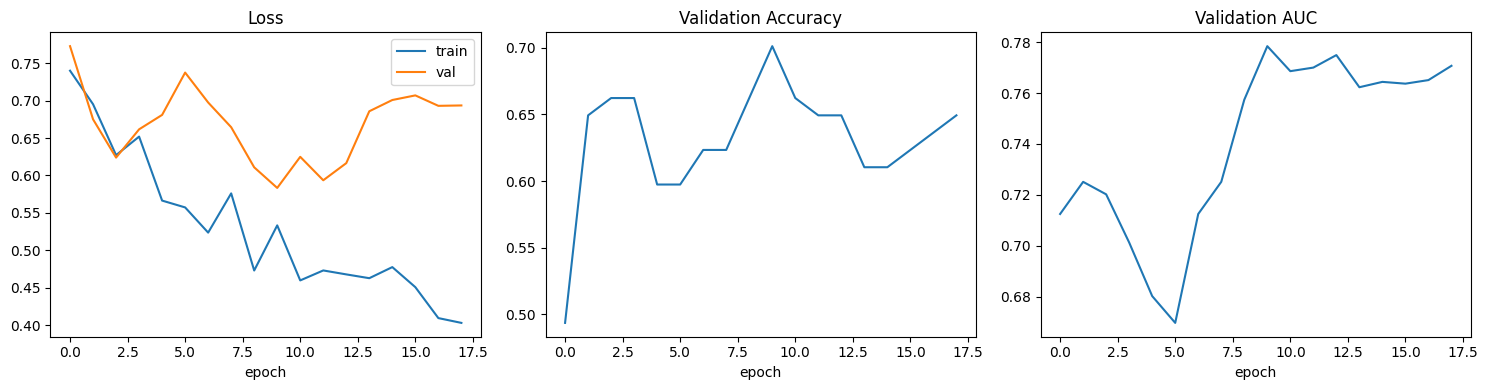

In [ ]:
# 訓練曲線
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(history["train_loss"], label="train")
axes[0].plot(history["val_loss"],   label="val")
axes[0].set_title("Loss"); axes[0].set_xlabel("epoch"); axes[0].legend()
axes[1].plot(history["val_acc"])
axes[1].set_title("Validation Accuracy"); axes[1].set_xlabel("epoch")
axes[2].plot(history["val_auc"])
axes[2].set_title("Validation AUC"); axes[2].set_xlabel("epoch")
plt.tight_layout()
plt.savefig("training_curves_v2.png", dpi=120)
plt.show()

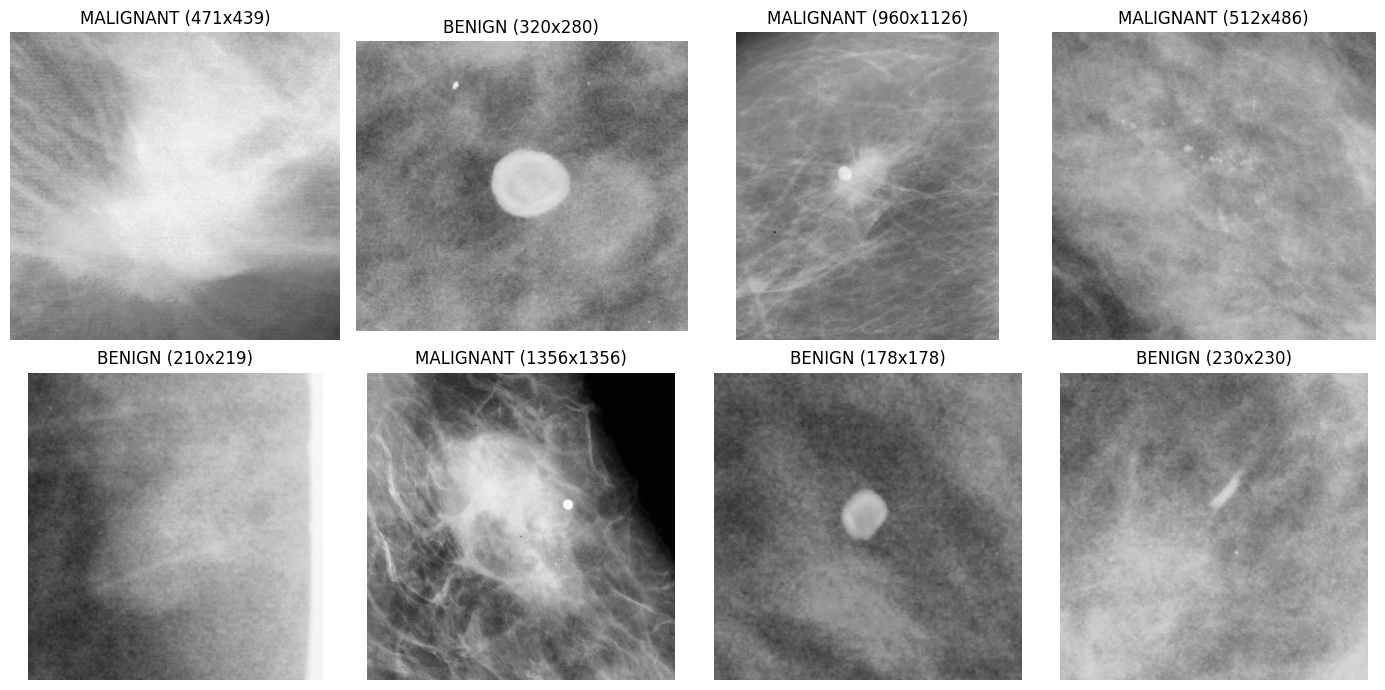

In [ ]:
# 視覺化幾個 bbox-crop 樣本（檢查裁切結果合理）
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
sample_df = df_train.sample(8, random_state=0).reset_index(drop=True)
for i, row in sample_df.iterrows():
    ax = axes[i // 4, i % 4]
    img = Image.open(row["full_image_path"]).convert("RGB")
    bbox = get_lesion_bbox(row["mask_path"], CONFIG["bbox_margin"])
    if bbox:
        img = img.crop(bbox)
    ax.imshow(img, cmap="gray")
    ax.set_title(f"{row['class']} ({img.size[0]}x{img.size[1]})")
    ax.axis("off")
plt.tight_layout()
plt.savefig("sample_crops.png", dpi=120)
plt.show()

In [ ]:
print("\n已儲存: best_model_v2.pt, training_curves_v2.png, sample_crops.png")


已儲存: best_model_v2.pt, training_curves_v2.png, sample_crops.png


In [3]:
import os
print("檔案列表:")
for f in sorted(os.listdir('/content/')):
    if os.path.isfile(f'/content/{f}'):
        size = os.path.getsize(f'/content/{f}')
        print(f"  {f} ({size:,} bytes)")



檔案列表:
